In [299]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
from ibm_bridge import *
from rodeo.ode import *
import ode_bridge as bsol
import double_filter as df
from fenrir_filter import fenrir_filter

from jax.config import config
config.update("jax_enable_x64", True)

def abs_err(arr1, arr2):
    return np.sum(np.abs(arr1 - arr2))

def fitz(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:,0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                    [-1/c*(V - a + b*R)]])


In [300]:
# problem setup and intialization
n_deriv = 3  # Total state
n_var = 2  # Total measures
n_dim = 2

# it is assumed that the solution is sought on the interval [tmin, tmax].
n_steps = 200
tmin = 0.
tmax = 40.
theta = np.array([0.2, 0.2, 3])
thetaj = jnp.array(theta)

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = 1
sigma = jnp.array([sigma]*n_var)

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# Initial x0 for jax block
x0_block = jnp.array([[-1., 1., 1.], [1., 1/3, -0.3555555555555555]])
# x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_steps
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)

tseq = jnp.linspace(tmin, tmax, n_steps+1)

# Jit solver
key = jax.random.PRNGKey(0)
sim_jit = jax.jit(solve_mv, static_argnums=(1, 7))
sim, _ = sim_jit(key=key, fun=fitz,
        x0=x0_block, theta=thetaj,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init)

In [301]:
def fitz0(X_t, t, theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])


In [302]:
from scipy.integrate import odeint
import numpy as np
n_obs = 40
tseq1 = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(fitz0, ode0, tseq1, args=(theta,))
#der = jnp.array([fitz0(exact[t],tseq[t],theta) for t in range(n_eval+1)])

In [303]:
gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

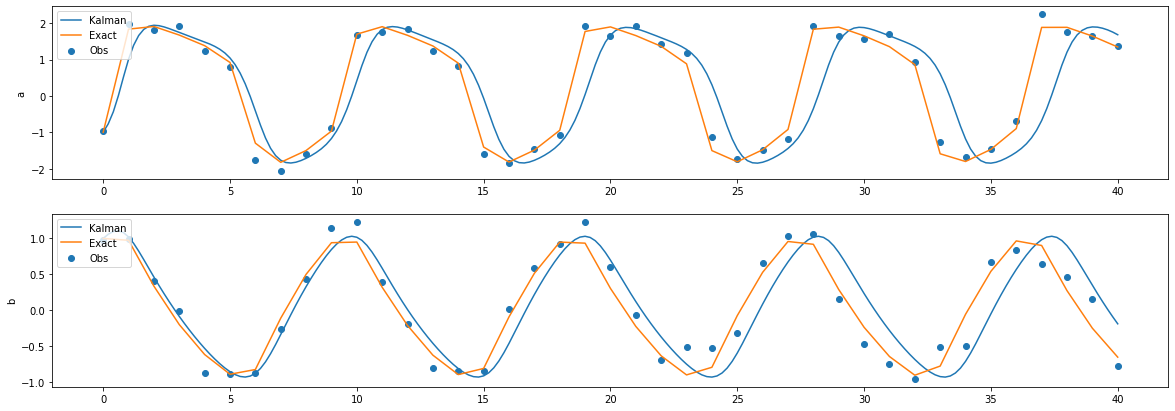

In [6]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['a', 'b', 'c']
for i in range(n_dim):
    axs[i].plot(tseq,sim[:,i, 0], label="Kalman")
    #axs[i].plot(tseq, knum_sim[:, n_deriv_prior[0]*i], label="Kalman2")
    axs[i].set_ylabel(ylabel[i])
    axs[i].plot(tseq1, exact[:, i], label='Exact')
    axs[i].scatter(tseq1, obs[:, i], label='Obs')
    axs[i].legend(loc='upper left')

In [421]:
n_res = 4
n_steps = n_res*n_obs
dt = (tmax-tmin)/n_steps
gamma = 0.2
sigma = 10
sigma = jnp.array([sigma]*n_var)
Omega = (gamma)**2*jnp.ones((2,1,1))
#Omega = jax.vmap(lambda b: sigma[b]*sigma[b]*Omega[b])(jnp.arange(n_obs))
Y = jnp.expand_dims(obs, -1)
# Y = jnp.zeros((n_eval, ))
WW = jnp.array([[[1., 0., 0.]], [[1., 0., 0.]]])
bridge_init = ibm_bridge_init(n_res, dt, n_order, sigma, Y[1:], WW, Omega)

In [380]:
thetaj2 = np.array([.2, .2, 3])

In [422]:
ode_init = ibm_init(dt, n_order, sigma)
mv_o, _ = solve_mv(key=key, fun=fitz,
    x0=x0_block, theta=thetaj2,
    tmin=tmin, tmax=tmax, n_steps=n_steps,
    W=W_block, **ode_init, interrogate=interrogate_tronarp)

In [382]:
key = jax.random.PRNGKey(0)
sim_jit2 = jax.jit(bsol.solve_sim, static_argnums=(1, 7,11))
draws = 100
# sim2 = np.zeros((draws, n_steps+1, 2, 3))
# for i in range(draws):
#     key, subkey = jax.random.split(key)
#     sim2[i] = sim_jit2(key=subkey, fun=fitz,
#             x0=x0_block, theta=thetaj,
#             tmin=tmin, tmax=tmax, n_steps=n_steps,
#             W=W_block, **bridge_init, interrogate=interrogate_rodeo)
mv_b, _= bsol.solve_mv(
    key=key, fun=fitz,
    x0=x0_block, theta=thetaj2,
    tmin=tmin, tmax=tmax, n_steps=n_steps,
    W=W_block, **bridge_init, interrogate=interrogate_rodeo
)

In [423]:
trans_obs = jnp.array([[[1., 0., 0.]], [[1., 0., 0.]]])
mean_obs = jnp.zeros((2, 1))
var_obs = gamma**2*jnp.array([[[1.]],[[1.]]])

In [424]:
mv, _ = df.solve_mv(
    key=key, fun=fitz,
    W=W_block, x0=x0_block, theta=thetaj2,
    tmin=tmin, tmax=tmax, n_res=n_res,
    trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], 
    var_state=ode_init['var_state'],
    trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs,
    y_obs = Y, interrogate=interrogate_tronarp)

In [392]:
mv_f, _ = fenrir_filter(
    key=key, fun=fitz,
    W=W_block, x0=x0_block, theta=thetaj2,
    tmin=tmin, tmax=tmax, n_res=n_res,
    trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], 
    var_state=ode_init['var_state'],
    trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs,
    y_obs = Y, interrogate=interrogate_rodeo)

In [425]:
tseq_sim = np.linspace(tmin, tmax, n_steps+1)
exact_sim = odeint(fitz0, ode0, tseq_sim, args=(thetaj,))

In [387]:
print("bridge: {}".format(abs_err(exact_sim[::n_res, [0,1]], mv_b[::n_res, [0,1], 0])))
print("original: {}".format(abs_err(exact_sim[::n_res, [0,1]], mv_o[::n_res, [0,1], 0])))
print("fenrir: {}".format(abs_err(exact_sim[::n_res, [0,1]], mv_f[::n_res, [0,1], 0])))
print("double: {}".format(abs_err(exact_sim[::n_res, [0,1]], mv[::n_res, [0,1], 0])))

bridge: 10.54065278963037
original: 34.29245452000679
fenrir: 19.385483428403127
double: 12.278569332902265


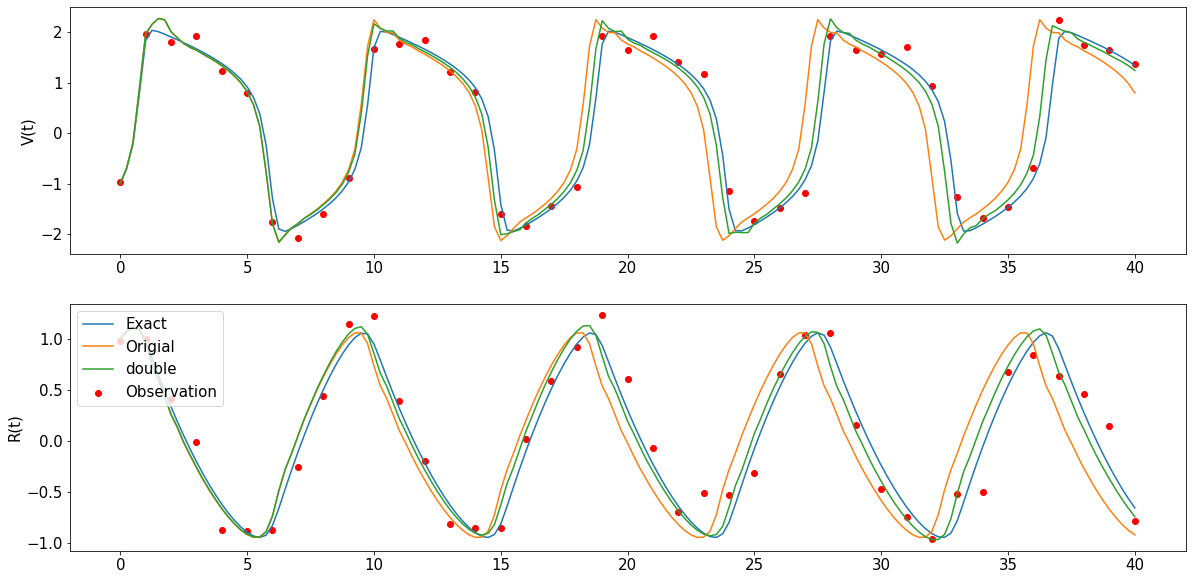

In [426]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(n_dim, 1, figsize=(20, 10))
y_label = ['V(t)', 'R(t)']
plt.rcParams.update({'font.size': 15})
for i in range(n_dim):
    axs[i].set_ylabel(y_label[i])
    # for j in range(draws):
        # axs[i].plot(tseq_sim, sim2[j, :, i, 0], alpha=0.5, color="grey")
    axs[i].plot(tseq_sim, exact_sim[:, i], label='Exact')
    axs[i].plot(tseq_sim, mv_o[:,i, 0], label="Origial")
    # axs[i].plot(tseq_sim, mv_b[:,i, 0], label="Bridge Proposal")
    axs[i].plot(tseq_sim, mv[:, i, 0], label="double")
    axs[i].scatter(tseq1, obs[:, i], label='Observation', color='red')
axs[1].legend(loc='upper left')


In [433]:
# ODE function
def lorenz(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t[:,0]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([[dx], [dy], [dz]])

# problem setup and intialization
n_deriv = 3  # Total state; q
n_var = 3  # Total observations

# Time interval on which a solution is sought.
tmin = 0.
tmax = 20.
theta = jnp.array([28, 10, 8/3])

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for jax block
x0_block = jnp.array([[-12., 70., 550.], [-5., 125, -1321.], [38., -124/3, -15658/9]])
n_order = jnp.array([n_deriv]*n_var)

In [453]:
def lorenz0(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return np.array([dx, dy, dz])

# Initial x0 for odeint
ode0 = jnp.array([-12., -5., 38.])

# Get exact solutions for the Lorenz System
n_obs = 200
tseq = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(lorenz0, ode0, tseq, args=(theta,), rtol=1e-20)
gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

In [490]:
Y = jnp.expand_dims(obs, -1)
mean_obs = jnp.zeros((n_var, 1))
trans_obs = np.zeros((n_var, 1, n_deriv))
trans_obs[:, :, 0] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.ones((n_var, 1, 1))
n_res = 5000
sigma = 5e3
sigma = jnp.array([sigma]*n_var)
n_steps = n_res*n_obs
dt = (tmax-tmin)/n_steps
ode_init = ibm_init(dt, n_order, sigma)
key = jax.random.PRNGKey(0)

In [278]:
n=20
do_err = np.zeros((n+1))
o_err = np.zeros((n+1))
for i in range(10,n+1):
    n_res = 5*i*2
    n_steps = n_res*n_obs
    dt = (tmax-tmin)/n_steps
    ode_init = ibm_init(dt, n_order, sigma)
    mv_o, _ = solve_mv(key=key, fun=lorenz,
        x0=x0_block, theta=theta,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init, interrogate=interrogate_rodeo)
    mv, _ = df.solve_mv(
        key=key, fun=lorenz,
        W=W_block, x0=x0_block, theta=theta,
        tmin=tmin, tmax=tmax, n_res=n_res,
        trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], 
        var_state=ode_init['var_state'],
        trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs,
        y_obs = Y, interrogate=interrogate_rodeo)
    do_err[i] = abs_err(exact, mv[::n_res, :, 0])
    o_err[i] = abs_err(exact, mv_o[::n_res, :, 0])

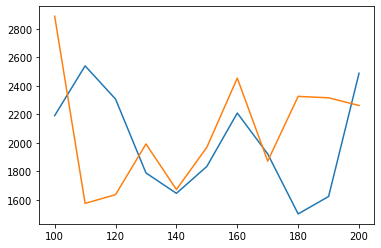

In [283]:
plt.plot(np.linspace(100, 5*n*2, 11), do_err[10:])
plt.plot(np.linspace(100, 5*n*2, 11), o_err[10:])

In [477]:
bridge_init = ibm_bridge_init(n_res, dt, n_order, sigma, Y[1:], trans_obs, var_obs)

In [491]:
theta2 = jnp.array([0,0,0])
theta = jnp.array([28, 10, 8/3])

In [478]:
mv_b, _= bsol.solve_mv(
    key=key, fun=lorenz,
    x0=x0_block, theta=theta,
    tmin=tmin, tmax=tmax, n_steps=n_steps,
    W=W_block, **bridge_init, interrogate=interrogate_rodeo
)

In [492]:
mv_o, _ = solve_mv(key=key, fun=lorenz,
        x0=x0_block, theta=theta,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init, interrogate=interrogate_rodeo)

In [493]:
mv, _ = df.solve_mv(
    key=key, fun=lorenz,
    W=W_block, x0=x0_block, theta=theta,
    tmin=tmin, tmax=tmax, n_res=n_res,
    trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], 
    var_state=ode_init['var_state'],
    trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs,
    y_obs = Y, interrogate=interrogate_rodeo)

In [61]:
mv_f, _ = fenrir_filter(
    key=key, fun=lorenz,
    W=W_block, x0=x0_block, theta=theta,
    tmin=tmin, tmax=tmax, n_res=n_res,
    trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], 
    var_state=ode_init['var_state'],
    trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs,
    y_obs = Y, interrogate=interrogate_rodeo)

In [494]:
tseq_sim = np.linspace(tmin, tmax, n_steps+1)
exact_sim = odeint(lorenz0, ode0, tseq_sim, args=(theta,), rtol=1e-20)

In [495]:
print("original: {}".format(abs_err(exact, mv_o[::n_res, :, 0])))
# print("fenrir: {}".format(abs_err(exact, mv_f[::n_res, :, 0])))
# print("bridge: {}".format(abs_err(exact, mv_b[::n_res, :, 0])))
print("double: {}".format(abs_err(exact, mv[::n_res, :, 0])))
print("obs: {}".format(abs_err(exact, Y[:, :, 0])))

original: 100.20710127642782
double: 101.27349444542101
obs: 96.10849411187782


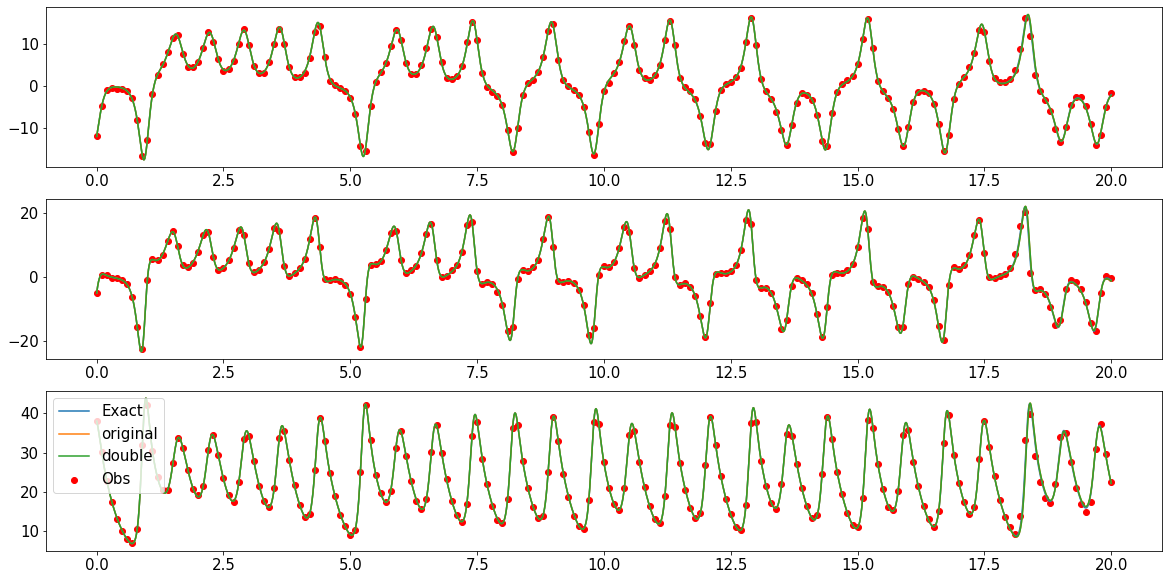

In [496]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_var, 1, figsize=(20, 10))
ylabel = ['x', 'y', 'z']
for i in range(n_var):
    axs[i].plot(tseq_sim, exact_sim[:, i], label='Exact')
    axs[i].plot(tseq_sim, mv_o[:, i, 0], label='original')
    # axs[i].plot(tseq_sim, mv_f[:, i, 0], label='fenrir')
    axs[i].plot(tseq_sim, mv[:, i, 0], label='double')
    # axs[i].plot(tseq_sim, mv_b[:, i, 0], label='bridge')
    axs[i].scatter(tseq, obs[:, i], label='Obs', color='red')
axs[i].legend(loc='upper left')